Import Libraries

In [1]:
import os
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import timm

Reproducibility

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Device (Local GPU)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Data Augmentation

In [4]:
from torchvision import transforms

# ---------------------------
# Train Transforms (Improved for ViT)
# ---------------------------
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0),
        ratio=(0.75, 1.33)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ---------------------------
# Validation / Test Transforms
# ---------------------------
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Load Dataset

In [ ]:
from torchvision import datasets
from torch.utils.data import random_split
import torch

dataset_path = "/home/ex5/Downloads/21MIS1007/Cashew_Dataset"

# Create base dataset WITHOUT transform
full_dataset = datasets.ImageFolder(root=dataset_path)

total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_indices, val_indices, test_indices = random_split(
    range(total_size),
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Now create datasets WITH transforms
train_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root=dataset_path, transform=train_transforms),
    train_indices.indices
)

val_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root=dataset_path, transform=val_transforms),
    val_indices.indices
)

test_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(root=dataset_path, transform=val_transforms),
    test_indices.indices
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 4609
Val: 987
Test: 989


DataLoaders

In [6]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

Load ViT Model

In [7]:
num_classes = len(full_dataset.classes)

model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=num_classes
)

model = model.to(device)

Loss, Optimizer, Scheduler

In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
EPOCHS = 200
# ---------------------------
# Compute Class Weights
# ---------------------------
labels = [label for _, label in train_dataset]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# ---------------------------
# Loss Function (Weighted)
# ---------------------------
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ---------------------------
# Optimizer (Lower LR for ViT)
# ---------------------------
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,              # Reduced from 3e-4
    weight_decay=0.05
)

# ---------------------------
# Scheduler (Better for ViT)
# ---------------------------
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

Training

In [10]:
EPOCHS = 200
best_val_loss = float('inf')
patience = 15
counter = 0

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(EPOCHS):

    # ---------------------
    # TRAINING PHASE
    # ---------------------
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * labels.size(0)
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # ---------------------
    # VALIDATION PHASE
    # ---------------------
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * labels.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # ---------------------
    # STORE METRICS
    # ---------------------
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # ---------------------
    # SCHEDULER STEP
    # ---------------------
    if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(val_loss)
    else:
        scheduler.step()

    # ---------------------
    # PRINT PROGRESS
    # ---------------------
    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # ---------------------
    # EARLY STOPPING
    # ---------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_vit_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

# ---------------------
# LOAD BEST MODEL
# ---------------------
model.load_state_dict(torch.load("best_vit_model.pth"))
model.eval()

print("\nTraining Complete. Best model loaded.")


Epoch [1/200]
Train Loss: 0.3045 | Train Acc: 0.8776
Val Loss: 0.1731 | Val Acc: 0.9412

Epoch [2/200]
Train Loss: 0.1853 | Train Acc: 0.9340
Val Loss: 0.1365 | Val Acc: 0.9625

Epoch [3/200]
Train Loss: 0.1173 | Train Acc: 0.9575
Val Loss: 0.1514 | Val Acc: 0.9443

Epoch [4/200]
Train Loss: 0.0966 | Train Acc: 0.9664
Val Loss: 0.1516 | Val Acc: 0.9514

Epoch [5/200]
Train Loss: 0.0939 | Train Acc: 0.9642
Val Loss: 0.1452 | Val Acc: 0.9493

Epoch [6/200]
Train Loss: 0.1017 | Train Acc: 0.9646
Val Loss: 0.1510 | Val Acc: 0.9473

Epoch [7/200]
Train Loss: 0.0752 | Train Acc: 0.9729
Val Loss: 0.1373 | Val Acc: 0.9544

Epoch [8/200]
Train Loss: 0.0848 | Train Acc: 0.9675
Val Loss: 0.1035 | Val Acc: 0.9585

Epoch [9/200]
Train Loss: 0.1215 | Train Acc: 0.9575
Val Loss: 0.3905 | Val Acc: 0.8409

Epoch [10/200]
Train Loss: 0.1407 | Train Acc: 0.9507
Val Loss: 0.1465 | Val Acc: 0.9473

Epoch [11/200]
Train Loss: 0.0695 | Train Acc: 0.9750
Val Loss: 0.1163 | Val Acc: 0.9625

Epoch [12/200]
Tra

Plot Curves

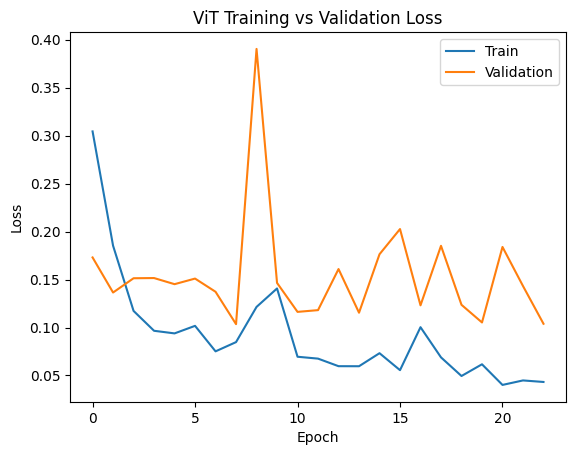

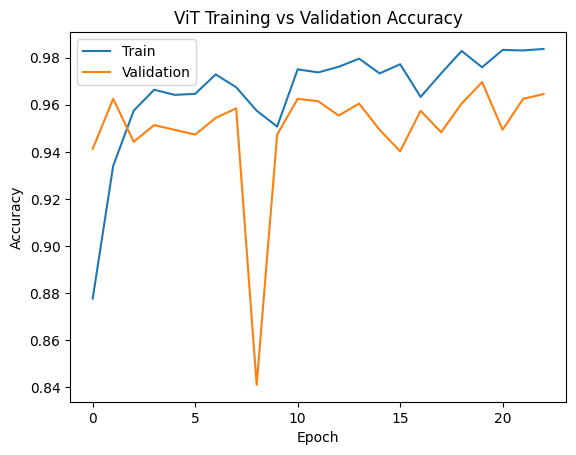

In [11]:
# Loss Curve
plt.figure()
plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ViT Training vs Validation Loss")
plt.legend(["Train", "Validation"])
plt.show()

# Accuracy Curve
plt.figure()
plt.plot(train_accuracies)
plt.plot(val_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ViT Training vs Validation Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

Test Evaluation + Confusion Matrix

Test Accuracy: 0.9524772497472194

Classification Report:

                    precision    recall  f1-score   support

Cashew anthracnose       0.90      0.93      0.92       242
    Cashew gumosis       1.00      0.98      0.99        61
    Cashew healthy       0.97      0.97      0.97       218
 Cashew leaf miner       0.94      0.92      0.93       206
   Cashew red rust       0.98      0.97      0.98       262

          accuracy                           0.95       989
         macro avg       0.96      0.96      0.96       989
      weighted avg       0.95      0.95      0.95       989



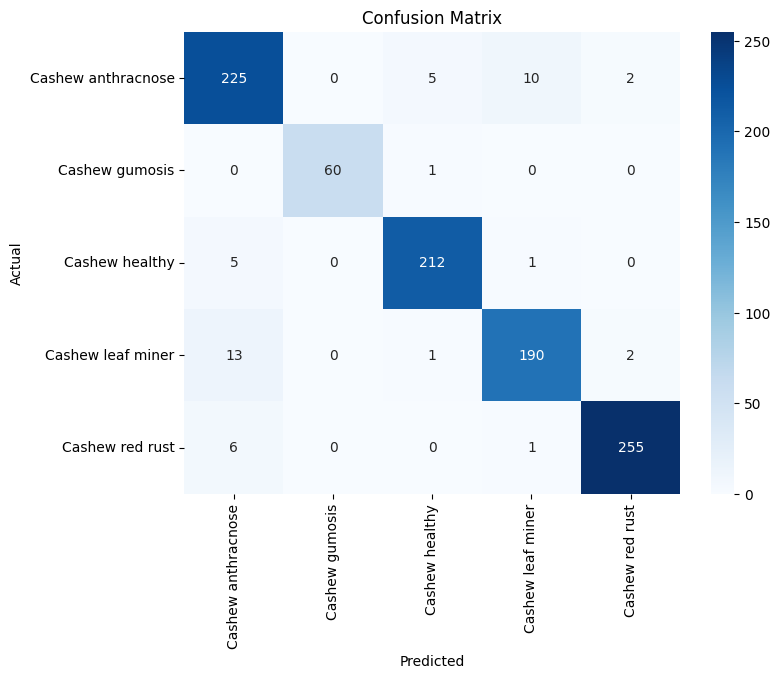

In [12]:
model.load_state_dict(torch.load("best_vit_model.pth"))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Grad CAM Visualization

In [ ]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

model.eval()

gradients = []
activations = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

# Hook last transformer block output
target_layer = model.blocks[-1].norm1
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)


def generate_vit_gradcam(image_tensor):
    gradients.clear()
    activations.clear()

    image_tensor = image_tensor.unsqueeze(0).to(device)

    output = model(image_tensor)
    pred_class = torch.argmax(output, dim=1).item()

    loss = output[0, pred_class]
    model.zero_grad()
    loss.backward()

    grad = gradients[0].detach().cpu().numpy()
    act = activations[0].detach().cpu().numpy()

    # Remove CLS token (first token)
    grad = grad[:, 1:, :]
    act = act[:, 1:, :]

    # Average gradients across embedding dimension
    weights = np.mean(grad, axis=2)

    cam = np.sum(weights[..., np.newaxis] * act, axis=2)

    # Reshape tokens into 14x14 grid (224/16 = 14)
    cam = cam.reshape(14, 14)

    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)

    cam = cv2.resize(cam, (224, 224))

    return cam, pred_class

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


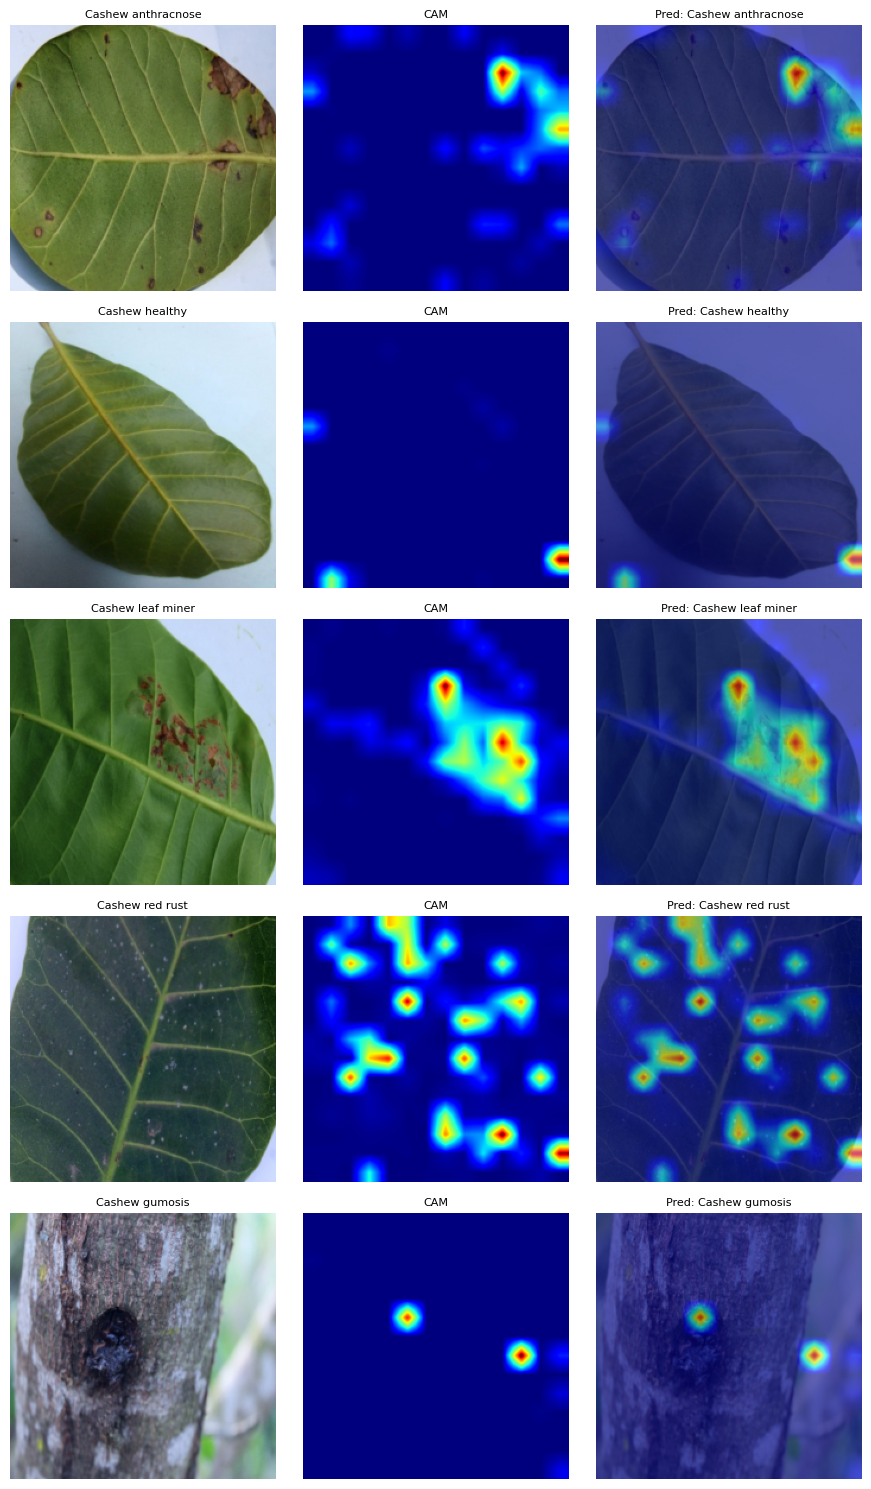

In [19]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random

model.eval()

class_names = full_dataset.classes
num_classes = len(class_names)

# -----------------------------
# Random one image per class
# -----------------------------
samples_per_class = {}

indices = list(range(len(test_dataset)))
random.shuffle(indices)

for idx in indices:
    img, label = test_dataset[idx]
    if label not in samples_per_class:
        samples_per_class[label] = img
    if len(samples_per_class) == num_classes:
        break

# -----------------------------
# Smaller Visualization
# -----------------------------
plt.figure(figsize=(9, 3 * num_classes))  # Smaller figure

for i, (label, img) in enumerate(samples_per_class.items()):

    cam, pred_class = generate_vit_gradcam(img)

    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    heatmap = heatmap / 255.0

    overlay = 0.6 * heatmap + 0.4 * img_np

    # Original
    plt.subplot(num_classes, 3, i*3 + 1)
    plt.imshow(img_np)
    plt.title(class_names[label], fontsize=8)
    plt.axis("off")

    # Grad-CAM
    plt.subplot(num_classes, 3, i*3 + 2)
    plt.imshow(cam, cmap="jet")
    plt.title("CAM", fontsize=8)
    plt.axis("off")

    # Overlay
    plt.subplot(num_classes, 3, i*3 + 3)
    plt.imshow(overlay)
    plt.title(f"Pred: {class_names[pred_class]}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()